In [15]:
import os
print(os.getcwd())

C:\Users\darks\Desktop\자료들\ai자료\ai\Country_Economy_Project


In [16]:
import pandas as pd

1 . 데이터 수정

In [17]:
df = pd.read_csv("country_power_data.csv")
df.head()

,country,code,year,gdp,exports_usd,hightech_exports,military_usd,military_per_gdp,patent_residents,population,rd_spending,gdp_per_capita,military_ratio,tech_power,gdp_norm,military_norm,tech_norm,power_score
0,Eritrea,ERI,2011,2.065002e+09,3.748977e+08,0.0,0.000000e+00,NaN,0,2998485,NaN,688.681660,0.000000,0.0,0.000070,0.000000,0.000000,0.000035
1,South Sudan,SSD,2015,1.199780e+10,4.397356e+09,0.0,1.151920e+09,8.603653,0,11107561,NaN,1080.147186,0.096011,0.0,0.000415,0.001155,0.000000,0.000554
2,"Yemen, Rep.",YEM,2018,2.160616e+10,1.891858e+09,0.0,0.000000e+00,NaN,0,34085182,NaN,633.887202,0.000000,0.0,0.000749,0.000000,0.000000,0.000375
3,Cuba,CUB,2020,1.073520e+11,8.769000e+09,17896042.0,0.000000e+00,NaN,33,11176354,0.51838,9605.279146,0.000000,17896075.0,0.003732,0.000000,0.000021,0.001870
4,St. Martin (French part),MAF,2021,6.492063e+08,NaN,0.0,0.000000e+00,NaN,0,29961,NaN,21668.377650,0.000000,0.0,0.000020,0.000000,0.000000,0.000010


In [18]:
df = df.drop(columns=[
    "rd_spending",        # 거의 없음
    "military_per_gdp"    # 결측 많음
])

In [19]:
df = df[[
    "country",
    "year",
    "gdp",
    "military_usd",
    "hightech_exports",
    "patent_residents",
    "population"
]]

In [20]:
# 핵심 변수 기준으로 제거
df = df.dropna(subset=[
    "gdp",
    "military_usd",
    "hightech_exports"
])

In [21]:
df["tech_power"] = (
    df["hightech_exports"] * 0.5 +
    df["gdp"] * 0.5   # 기술력 보정용
)

In [22]:
#정규화
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["gdp_norm", "military_norm", "tech_norm"]] = scaler.fit_transform(
    df[["gdp", "military_usd", "tech_power"]]
)

In [23]:
#국력 점수 다시 만들기
from sklearn.preprocessing import MinMaxScaler

df["population_norm"] = scaler.fit_transform(df[["population"]])

df["power_score"] = (
    df["gdp_norm"] * 0.5 +
    df["military_norm"] * 0.3 +
    df["tech_norm"] * 0.15 +
    df["population_norm"] * 0.05
)

In [24]:
df.sort_values("power_score", ascending=False).head(10)

,country,year,gdp,military_usd,hightech_exports,patent_residents,population,tech_power,gdp_norm,military_norm,tech_norm,population_norm,power_score
124,United States,2024,2.875100e+13,9.973090e+11,2.329070e+11,0,340110988,1.449195e+13,1.000000,1.000000,1.000000,0.234403,0.961720
145,China,2024,1.874380e+13,3.136580e+11,8.567650e+11,0,1408975000,9.800282e+12,0.651935,0.314504,0.676256,0.971080,0.570311
173,India,2024,3.909890e+12,8.612598e+10,5.414088e+10,0,1450935791,1.982015e+12,0.135990,0.086358,0.136765,1.000000,0.164417
193,Germany,2024,4.685590e+12,8.845848e+10,2.466380e+11,0,83516593,2.466114e+12,0.162970,0.088697,0.170169,0.057554,0.136497
161,Japan,2024,4.027600e+12,5.527390e+10,1.024510e+11,0,123975371,2.065026e+12,0.140084,0.055423,0.142493,0.085439,0.112315
120,United Kingdom,2024,3.686030e+12,8.176317e+10,8.476773e+10,0,69226000,1.885399e+12,0.128203,0.081984,0.130098,0.047705,0.110597
46,Russian Federation,2024,2.173840e+12,1.489670e+11,0.000000e+00,0,143533851,1.086920e+12,0.075607,0.149369,0.075000,0.098919,0.098810
198,France,2024,3.160440e+12,6.467502e+10,1.165910e+11,0,68551653,1.638516e+12,0.109923,0.064850,0.113062,0.047240,0.093737
164,Italy,2024,2.380830e+12,3.796458e+10,6.015686e+10,0,58952704,1.220493e+12,0.082807,0.038067,0.084217,0.040624,0.067487
128,Brazil,2024,2.185820e+12,2.094772e+10,8.694668e+09,0,211998573,1.097257e+12,0.076024,0.021004,0.075713,0.146106,0.062975


# 시각화

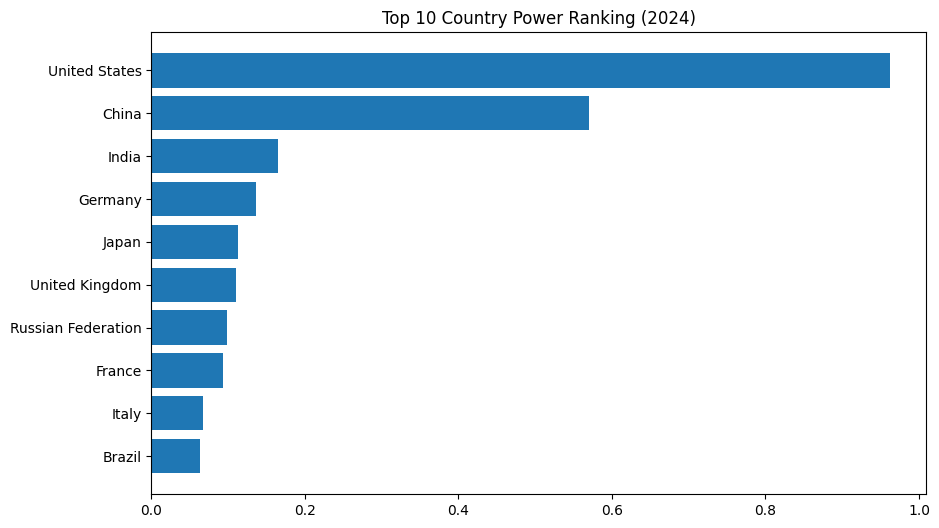

In [25]:
import matplotlib.pyplot as plt

top10 = df.sort_values("power_score", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["country"], top10["power_score"])
plt.gca().invert_yaxis()
plt.title("Top 10 Country Power Ranking (2024)")
plt.show()

In [47]:
df["power_level"] = pd.qcut(df["power_score"], 3, labels=["Low", "Mid", "High"])

# ai

In [48]:
X = df[[
    "gdp",
    "military_usd",
    "tech_power",
    "population"
]]

y = df["power_score"]

In [49]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

X = df[["gdp", "military_usd", "tech_power", "population"]]
y = df["power_score"]

model = RandomForestRegressor(random_state=42)

scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("각 폴드 R2:", scores)
print("평균 R2:", scores.mean())

각 폴드 R2: [0.93476938 0.97543674 0.62778809 0.93667165 0.91317465]
평균 R2: 0.8775681033582476


In [ ]:
# #
# “모델은 전반적으로 높은 설명력을 보이지만,
# 일부 국가에서는 예측 성능이 낮아지는 경향이 있다.”

# “이는 국가 간 구조적 차이
# (예: 중국, 인도, 러시아와 같은 특이 케이스) 때문으로 해석된다.”